# Results of human-AI collaboration

Example notebook for the object recognition task

## Load libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

## Define helper function to plot results

In [2]:
def plot_figure(df, mycolors, mymarkers, mymarksze, 
                figsize=(8,6), bbox_to_anchor=(0.5,1.2), lab_H='Human-only', low_noise=False):
    
    # Set the style and font using matplotlib
    plt.rc('font', family='Arial')
    plt.rc('axes', grid=True)
    plt.rc('axes', facecolor='white')

    # Create a figure and a set of subplots
    fig, ax = plt.subplots(figsize=figsize)

    # Font size
    fs = 16

    # Define the width of the dodge
    dodge_width = 0.2

    # Create a list of classifiers per type
    n_classifiers = np.arange(0, len(df['Classifier'].unique()))

    # Shift results if there is Human only team
    is_H_only = 0 

    # Create error bars
    for i, type in enumerate(df['Type'].unique()):
        type_data = df[df['Type'] == type]
        if i==0 and lab_H in type:
            y_coords = n_classifiers.min()
            is_H_only = 1
        else:
            y_coords = n_classifiers[is_H_only:] + (i-min(len(df['Type'].unique()),4)+1.5)*dodge_width
        ax.errorbar(type_data['Accuracy'], y_coords, xerr=type_data['SE'],
            fmt=mymarkers[type], markersize=mymarksze[type], capsize=0, color=mycolors[type],
            elinewidth=2, label=type)

    # Set x-axis limits
    ax.set_xlim([50, 80])
    ax.set_xticks([50, 55, 60, 65, 70, 75, 80])
    if low_noise:
        ax.set_xlim([75, 100])
        ax.set_xticks([75, 80, 85, 90, 95, 100])
    ax.set_xlabel("Accuracy (%)", fontsize=fs)  # Rename the x-axis label

    # Reverse the y-axis
    ax.set_yticks(n_classifiers, df['Classifier'].unique())
    ax.set_ylim(float(n_classifiers.min()-0.5), float(n_classifiers.max()+0.5))
    ax.invert_yaxis()

    # Increase the size of the tick labels
    ax.tick_params(axis='both', which='major', labelsize=fs)

    # Show the legend
    legend_elements = [Line2D([0], [0], marker=mymarkers[type], color='w', label=type,
        markerfacecolor=mycolors[type], markersize=3+mymarksze[type], linestyle='None')
            for type in df['Type'].unique()]
    ncol = len(df['Type'].unique())
    ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=bbox_to_anchor,
        ncol=ncol, frameon=False, fontsize=fs)
        
    # Show the plot
    plt.show()

## Plot prediction accuracies of standard and no confidence for low- and high-noise experiments

In [3]:
# Set labels for the type of team
lab_H, lab_M, lab_HM = 'Human-only', 'Machine-only', 'Human\u2013machine'

# Number of observations obtained from the paper
n = 1200

# Define custom colors for each type
mycolors  = {lab_H: '#FF7600', lab_M: '#1E88E5', lab_HM: '#158E6B'}
mymarkers = {lab_H: 'o',       lab_M: 'o',       lab_HM: 'D'}
mymarksze = {lab_H: 9,         lab_M: 9,         lab_HM: 8}

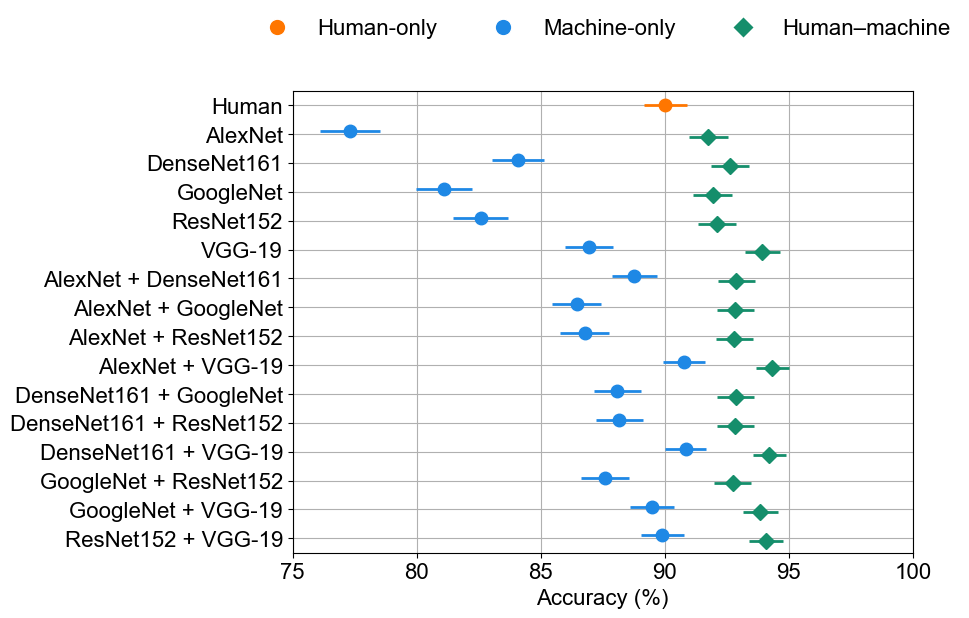

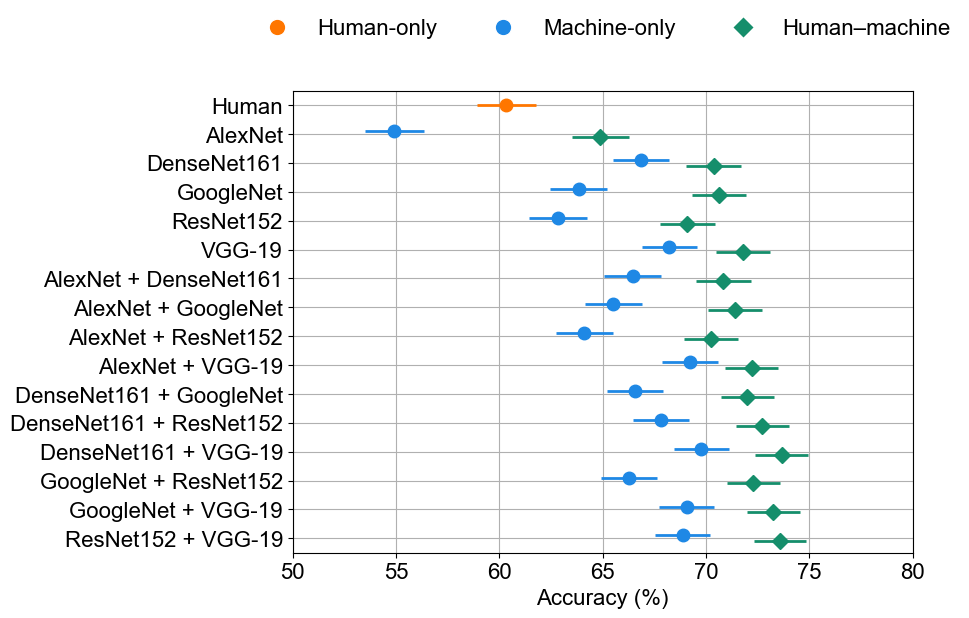

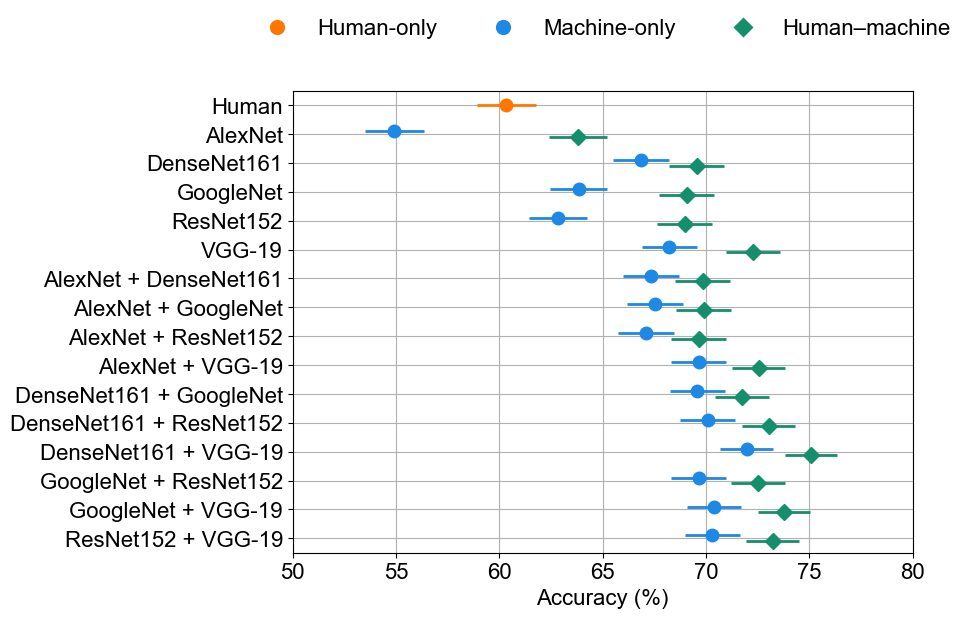

In [4]:
for noise_level, experiment_type in zip([80, 125, 125], ['standard', 'standard', 'no_confidence']):
    # Load the results for all team member combinations
    experiment_name = f'imagenet_{noise_level}_logistic_predictions_{experiment_type}_experiment'
    logistic_results = pd.read_csv(f'../results/{experiment_name}.csv')
    logistic_results.columns = ['Human', 'AlexNet', 'DenseNet161', 'GoogleNet', 'ResNet152', 'VGG-19', 'Accuracy']

    # Set type of team
    machines = list(logistic_results.iloc[:,1:-1].columns)
    df = logistic_results.copy()
    df['Classifier'] = df.iloc[:,1:-1].apply(lambda x: 'Human' if not x[machines].any() else ' + '.join([col for col in machines if x[col]]), axis=1)
    df['Type'] = df.iloc[:,:-2].apply(lambda x: lab_M if not x['Human'] else lab_HM if x.sum() > 1 else lab_H, axis=1)
    df['Accuracy'] = df['Accuracy'] * 100  

    # Calculate error bars (sem binomial data) for each point
    df['SE'] = df.apply(lambda x: np.sqrt(x['Accuracy'] * (100 - x['Accuracy']) / n), axis=1)

    # Plot Figure
    plot_figure(df, mycolors, mymarkers, mymarksze, low_noise=True if noise_level==80 else False)